# Exercitii

### **Exercitiul 1**

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

In [ ]:
X = torch.rand(1, 1, 7, 7)
conv2d = nn.Conv2d(1, 1, kernel_size=(4, 6), padding=(2, 1), stride=(3, 3))
conv2d(X).shape

torch.Size([1, 1, 3, 2])

### **Exercitiul 2**

In [ ]:
def load_data_svhn(batch_size, resize=None):
    """Download the SVHN dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    svhn_train = torchvision.datasets.SVHN(
        root="../data", split="train", transform=trans, download=True)
    svhn_test = torchvision.datasets.SVHN(
        root="../data", split="test", transform=trans, download=True)
    # print(len(svhn_train), len(svhn_test))
    svhn_train, svhn_val = torch.utils.data.random_split(svhn_train, [50000, 23257],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(svhn_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
load_data_svhn(2)

100%|██████████| 182M/182M [00:20<00:00, 8.97MB/s]
100%|██████████| 64.3M/64.3M [00:13<00:00, 4.82MB/s]


(<torch.utils.data.dataloader.DataLoader at 0x7d1aa2619580>,
 <torch.utils.data.dataloader.DataLoader at 0x7d1aa17dcb00>)

In [ ]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [ ]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
class Residual(nn.Module):
    """The Residual block of ResNet."""
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_channels)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None

    def forward(self, X):
        Y = nn.ReLU()(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return nn.ReLU()(Y)

In [ ]:
b1 = nn.Sequential(nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [ ]:
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

In [ ]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

In [ ]:
net = nn.Sequential(b1, b2, b3,
                    nn.AdaptiveAvgPool2d((1, 1)),
                    nn.Flatten(), nn.Linear(128, 10))
net

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (1): Sequential(
    (0): Residual(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Residual(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-

In [ ]:
batch_size, lr, num_epochs = 256, 0.9, 10
train_iter, val_iter, test_iter = load_data_svhn(batch_size, resize=96)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #11 min

Training on cuda:0


/tmp/ipython-input-2341657111.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(l)


Epoch 1, Train loss 2.31, Train accuracy 20.80, Validation loss 3.40, Validation accuracy 12.60
Epoch 2, Train loss 1.11, Train accuracy 62.93, Validation loss 1.99, Validation accuracy 42.40
Epoch 3, Train loss 0.39, Train accuracy 88.37, Validation loss 0.85, Validation accuracy 72.22
Epoch 4, Train loss 0.29, Train accuracy 91.41, Validation loss 0.84, Validation accuracy 71.60
Epoch 5, Train loss 0.24, Train accuracy 93.12, Validation loss 2.41, Validation accuracy 45.63
Epoch 6, Train loss 0.21, Train accuracy 93.93, Validation loss 0.44, Validation accuracy 86.92
Epoch 7, Train loss 0.19, Train accuracy 94.58, Validation loss 0.34, Validation accuracy 89.92
Epoch 8, Train loss 0.17, Train accuracy 95.10, Validation loss 0.39, Validation accuracy 88.61
Epoch 9, Train loss 0.15, Train accuracy 95.71, Validation loss 0.35, Validation accuracy 89.71
Epoch 10, Train loss 0.13, Train accuracy 96.20, Validation loss 0.65, Validation accuracy 82.02
Test loss 0.60, Test accuracy 83.12


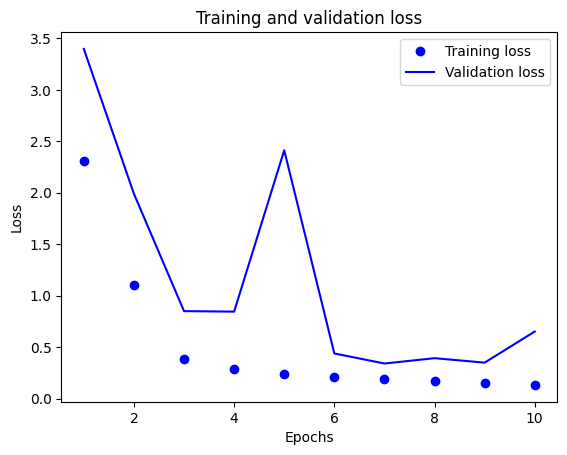

In [ ]:
plot_loss(train_loss_all, val_loss_all)

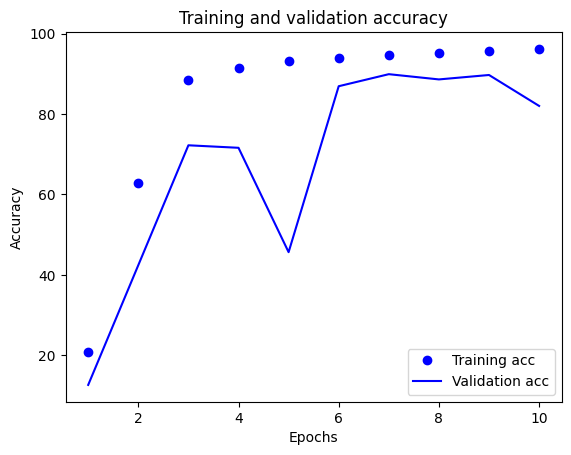

In [ ]:
plot_accuracy(train_acc_all, val_acc_all)

### **Exercitiul 3**

In [ ]:
def load_data_svhn(batch_size, resize=None):
    """Download the SVHN dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    svhn_train = torchvision.datasets.SVHN(
        root="../data", split="train", transform=trans, download=True)
    svhn_test = torchvision.datasets.SVHN(
        root="../data", split="test", transform=trans, download=True)
    # print(len(svhn_train), len(svhn_test))
    svhn_train, svhn_val = torch.utils.data.random_split(svhn_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(svhn_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_test, batch_size, shuffle=False,
                            num_workers=2))

In [ ]:
class ConvolutionalBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32,
                               kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 3,
                               kernel_size=1)
        self.bn2 = nn.BatchNorm2d(3)

    def forward(self, X):
        # print(X.shape)
        Y = nn.ReLU()(self.conv1(X))
        # print(Y.shape)
        Z = nn.ReLU()(self.bn2(self.conv2(Y)))
        # print(Z.shape)

        return X + Z

In [ ]:
net = nn.Sequential(ConvolutionalBlock(), nn.Flatten(), nn.Linear(3072, 10))
net

Sequential(
  (0): ConvolutionalBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
    (bn2): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=3072, out_features=10, bias=True)
)

In [ ]:
batch_size, lr, num_epochs = 256, 0.05, 5
train_iter, val_iter, test_iter = load_data_svhn(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #11 min

Training on cuda:0
Epoch 1, Train loss 6.36, Train accuracy 12.46, Validation loss 7.14, Validation accuracy 12.59
Epoch 2, Train loss 5.76, Train accuracy 13.07, Validation loss 5.89, Validation accuracy 19.62
Epoch 3, Train loss 5.80, Train accuracy 13.63, Validation loss 4.73, Validation accuracy 10.70
Epoch 4, Train loss 5.38, Train accuracy 13.89, Validation loss 4.81, Validation accuracy 7.77
Epoch 5, Train loss 5.41, Train accuracy 14.54, Validation loss 4.07, Validation accuracy 15.36
Test loss 4.13, Test accuracy 13.41


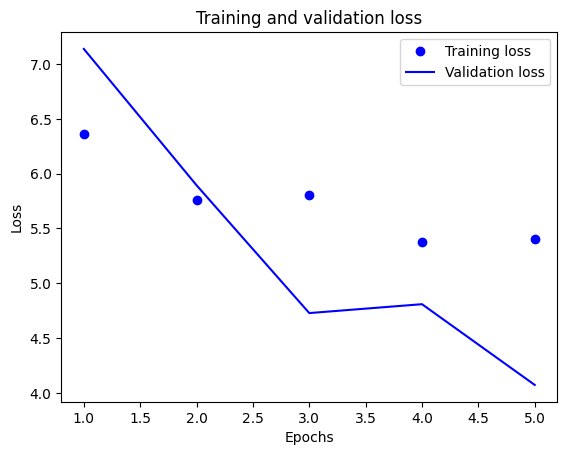

In [ ]:
plot_loss(train_loss_all, val_loss_all)

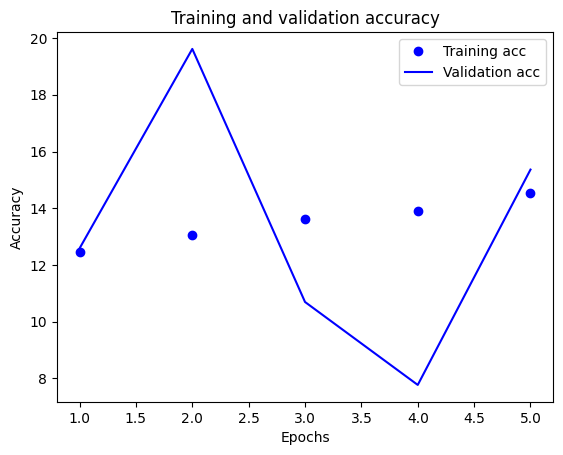

In [ ]:
plot_accuracy(train_acc_all, val_acc_all)